# Model Training & Evaluation
Training, tuning, and evaluating machine learning models for Customer Churn Prediction.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
import re
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.model_selection import cross_val_score, RandomizedSearchCV, learning_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, precision_recall_curve

## 2. Load Preprocessed Datasets

In [2]:
# Load data
X_train = pd.read_csv('../dataset/X_train.csv')
X_test = pd.read_csv('../dataset/X_test.csv')
y_train_raw = pd.read_csv('../dataset/y_train.csv')
y_test_raw = pd.read_csv('../dataset/y_test.csv')

# Sanitize feature names for LightGBM/XGBoost compatibility
X_train.columns = [re.sub(r'[\[\]<>{}:",]', '', col) for col in X_train.columns]
X_test.columns = [re.sub(r'[\[\]<>{}:",]', '', col) for col in X_test.columns]

# Encode target variable (Yes -> 1, No -> 0)
y_train = y_train_raw['Churn Label'].map({'Yes': 1, 'No': 0})
y_test = y_test_raw['Churn Label'].map({'Yes': 1, 'No': 0})

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

X_train shape: (5625, 2843)
y_train shape: (5625,)


## 3. Initialize Models

In [3]:
# Define base models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1)
}

## 4. 5-Fold Cross Validation (Base Models)

In [4]:
# Perform 5-Fold CV on training set
cv_results = []
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc')
    cv_results.append({
        'Model': name,
        'CV_ROC_AUC_Mean': scores.mean(),
        'CV_ROC_AUC_Std': scores.std()
    })
    
cv_df = pd.DataFrame(cv_results).sort_values(by='CV_ROC_AUC_Mean', ascending=False)
display(cv_df)

,Model,CV_ROC_AUC_Mean,CV_ROC_AUC_Std
4,LightGBM,0.853325,0.013832
2,Random Forest,0.848544,0.014860
3,XGBoost,0.846113,0.015736
0,Logistic Regression,0.843687,0.015764
1,Decision Tree,0.698103,0.017269


## 5. Hyperparameter Tuning (Random Forest & XGBoost)

In [5]:
# Hyperparameter grid for Random Forest
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_random = RandomizedSearchCV(estimator=models['Random Forest'], param_distributions=rf_params,
                               n_iter=5, cv=3, verbose=1, random_state=42, scoring='roc_auc', n_jobs=-1)
rf_random.fit(X_train, y_train)
print(f"Best RF Params: {rf_random.best_params_}")
print(f"Best RF CV ROC AUC: {rf_random.best_score_:.4f}")

Fitting 3 folds for each of 5 candidates, totalling 15 fits


Best RF Params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 20}
Best RF CV ROC AUC: 0.8559


In [6]:
# Hyperparameter grid for XGBoost
xgb_params = {
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_random = RandomizedSearchCV(estimator=models['XGBoost'], param_distributions=xgb_params,
                                n_iter=5, cv=3, verbose=1, random_state=42, scoring='roc_auc', n_jobs=-1)
xgb_random.fit(X_train, y_train)
print(f"Best XGB Params: {xgb_random.best_params_}")
print(f"Best XGB CV ROC AUC: {xgb_random.best_score_:.4f}")

Fitting 3 folds for each of 5 candidates, totalling 15 fits


Best XGB Params: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best XGB CV ROC AUC: 0.8636


## 6. Evaluate All Models on Test Set

In [7]:
# Update models dictionary with tuned models
models['Random Forest (Tuned)'] = rf_random.best_estimator_
models['XGBoost (Tuned)'] = xgb_random.best_estimator_

# Evaluation function
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    return {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC AUC': roc_auc_score(y_test, y_prob)
    }

# Evaluate all
eval_results = []
for name, model in models.items():
    # If model is not trained yet, fit it
    if name not in ['Random Forest (Tuned)', 'XGBoost (Tuned)']:
        model.fit(X_train, y_train)
    
    metrics = evaluate_model(model, X_test, y_test)
    metrics['Model'] = name
    eval_results.append(metrics)

eval_df = pd.DataFrame(eval_results).set_index('Model')
display(eval_df.sort_values(by='ROC AUC', ascending=False))

,Accuracy,Precision,Recall,F1 Score,ROC AUC
Model,,,,,
XGBoost (Tuned),0.801706,0.645260,0.564171,0.601997,0.848820
LightGBM,0.797441,0.636086,0.556150,0.593438,0.843147
Random Forest (Tuned),0.799574,0.678295,0.467914,0.553797,0.840201
Random Forest,0.798863,0.659649,0.502674,0.570561,0.836680
Logistic Regression,0.783937,0.604167,0.542781,0.571831,0.829465
XGBoost,0.775409,0.586310,0.526738,0.554930,0.821130
Decision Tree,0.760483,0.553009,0.516043,0.533887,0.682513


## 7. Select Best Model and Visualize Performance

In [8]:
# Select best model based on ROC AUC
best_model_name = eval_df['ROC AUC'].idxmax()
best_model = models[best_model_name]
print(f"Best Model Selected: {best_model_name}")

# Prepare predictions for plots
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

Best Model Selected: XGBoost (Tuned)


## 8. Visualizations

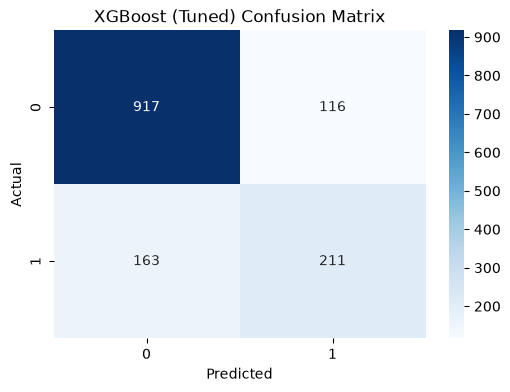

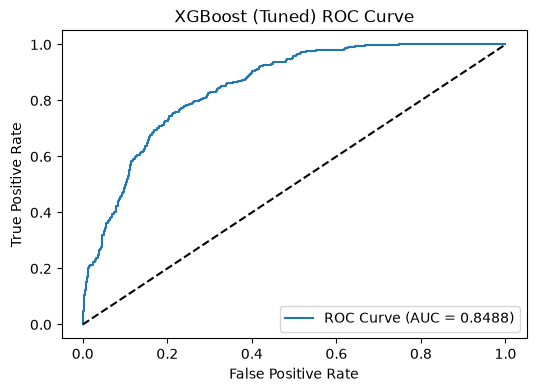

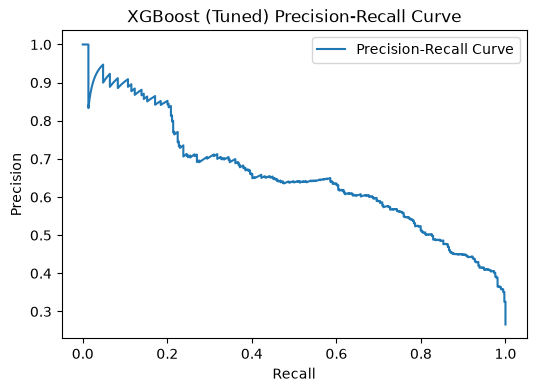

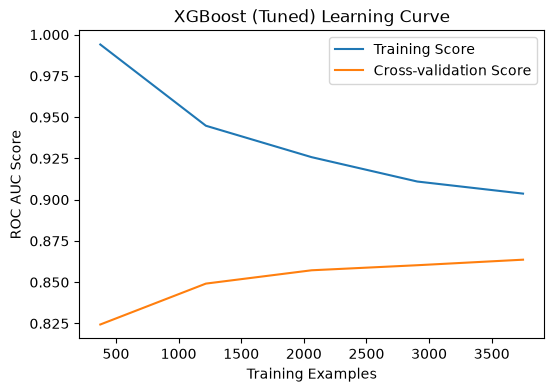

In [9]:
# 1. Confusion Matrix
plt.figure(figsize=(6,4))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'{best_model_name} Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_best)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {eval_df.loc[best_model_name, "ROC AUC"]:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title(f'{best_model_name} ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

# 3. Precision Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_prob_best)
plt.figure(figsize=(6,4))
plt.plot(recall, precision, label='Precision-Recall Curve')
plt.title(f'{best_model_name} Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()

# 4. Learning Curve
train_sizes, train_scores, test_scores = learning_curve(
    best_model, X_train, y_train, cv=3, n_jobs=-1, scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 5))
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(6,4))
plt.plot(train_sizes, train_mean, label='Training Score')
plt.plot(train_sizes, test_mean, label='Cross-validation Score')
plt.title(f'{best_model_name} Learning Curve')
plt.xlabel('Training Examples')
plt.ylabel('ROC AUC Score')
plt.legend()
plt.show()

## 9. Feature Importance

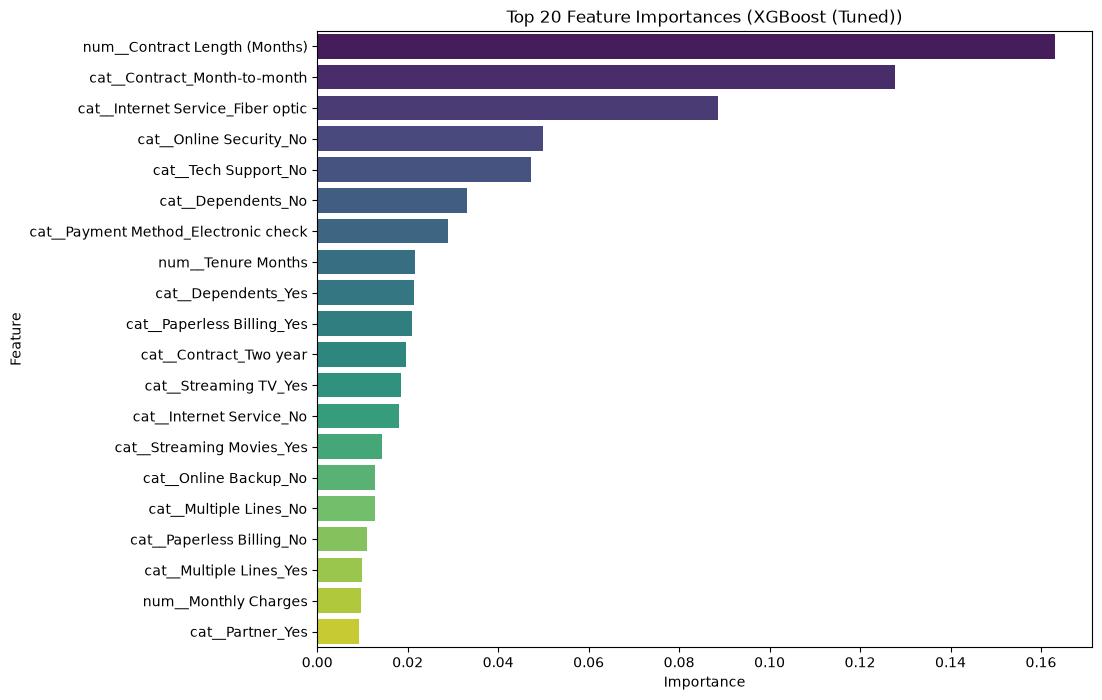

In [10]:
# Feature Importance Plot
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    features = X_train.columns
    imp_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)
    
    plt.figure(figsize=(10,8))
    sns.barplot(x='Importance', y='Feature', data=imp_df.head(20), palette='viridis')
    plt.title(f'Top 20 Feature Importances ({best_model_name})')
    plt.show()
else:
    print("Feature importances not available for this model type.")

## 10. Save Best Model

In [11]:
# Save best model to models directory
joblib.dump(best_model, '../models/best_model.pkl')
print(f"✅ Best model '{best_model_name}' saved to models/best_model.pkl")

✅ Best model 'XGBoost (Tuned)' saved to models/best_model.pkl
